In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Data loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customer

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


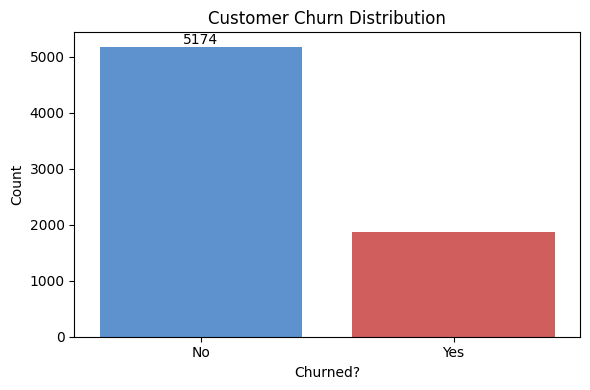

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Churn counts:")
print(churn_counts)
print("\nChurn percentage:")
print(churn_pct.round(1))
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#4A90E2', '#E24B4A'])
ax.bar_label(ax.containers[0])
plt.title('Customer Churn Distribution')
plt.xlabel('Churned?')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

<Figure size 800x500 with 0 Axes>

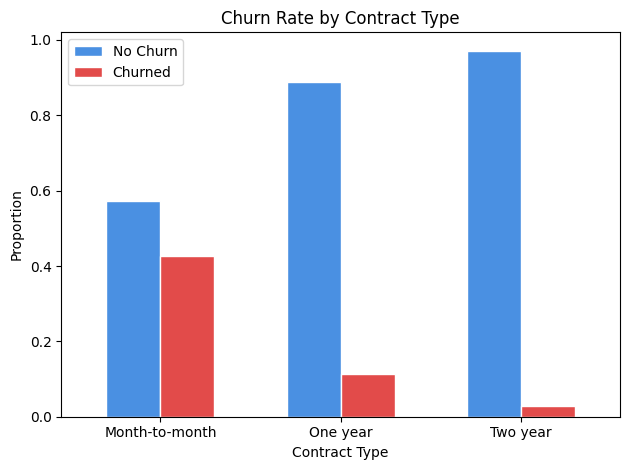

In [6]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', color=['#4A90E2', '#E24B4A'], edgecolor='white', width=0.6)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

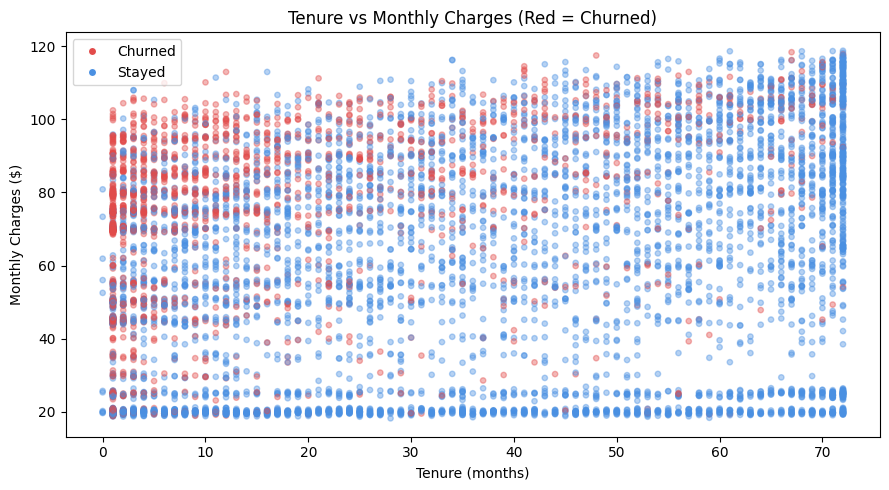

In [7]:
plt.figure(figsize=(9, 5))
colors = df['Churn'].map({'Yes': '#E24B4A', 'No': '#4A90E2'})
plt.scatter(df['tenure'], df['MonthlyCharges'], c=colors, alpha=0.4, s=15)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Tenure vs Monthly Charges (Red = Churned)')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', label='Churned'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#4A90E2', label='Stayed')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('tenure_vs_charges.png', dpi=150)
plt.show()

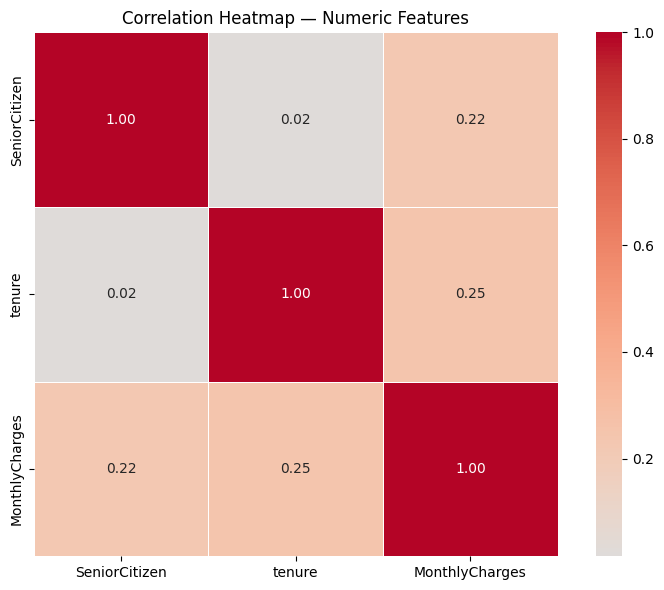

In [8]:

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
# Convert TotalCharges to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Check how many NaN values appeared
print("NaN values in TotalCharges:", df['TotalCharges'].isnull().sum())
# Fill NaN with 0 (these are new customers with no charges yet)
df['TotalCharges'].fillna(0, inplace=True)
print("✅ TotalCharges fixed")

NaN values in TotalCharges: 11
✅ TotalCharges fixed


In [10]:
# customerID is just a unique identifier — it has no predictive value.

df.drop(columns=['customerID'], inplace=True)
print("✅ customerID dropped")
print("Remaining columns:", df.shape[1])

✅ customerID dropped
Remaining columns: 20


In [11]:
#  Machine learning needs numbers, not 'Yes'/'No'. This converts Churn to 1/0.

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts after encoding:")
print(df['Churn'].value_counts())

Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
# Any column with text values gets converted to numbers using LabelEncoder.

le = LabelEncoder()
# Get all text (object) columns except Churn
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print("\n✅ All categorical columns encoded")
print("Sample of encoded data:")
df.head(3)

Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ All categorical columns encoded
Sample of encoded data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [13]:
#Split into features and target

#X = all input columns. y = the Churn column we're trying to predict.

X = df.drop(columns=['Churn'])
y = df['Churn']
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:\n", X.columns.tolist())

Features (X) shape: (7043, 19)
Target (y) shape: (7043,)

Feature columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [14]:
#Handle class imbalance with SMOTE

#SMOTE creates synthetic 'churned' examples so the model sees balanced data during training.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Before SMOTE:")
print("Train set — Churn=1:", y_train.sum(), "| Churn=0:", (y_train==0).sum())
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:")
print("Train set — Churn=1:", y_train_bal.sum(), "| Churn=0:", (y_train_bal==0).sum())
print("\n✅ Data balanced and ready for modelling!")

Before SMOTE:
Train set — Churn=1: 1495 | Churn=0: 4139

After SMOTE:
Train set — Churn=1: 4139 | Churn=0: 4139

✅ Data balanced and ready for modelling!


In [15]:
#Scale numeric features
# StandardScaler makes all numbers on the same scale. Important for Logistic Regression.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)
print("✅ Features scaled successfully")



✅ Features scaled successfully


In [16]:
#This trains Logistic Regression, Random Forest, and XGBoost. Takes ~1 minute.

# --- Model 1: Logistic Regression (baseline) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_bal)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_bal, y_train_bal)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
# --- Model 3: XGBoost ---
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print("✅ All 3 models trained!")

✅ All 3 models trained!


In [17]:
# ROC-AUC is the main metric for churn — higher is better. 0.5 = random, 1.0 = perfect.

results = {
    'Logistic Regression': roc_auc_score(y_test, lr_prob),
    'Random Forest':       roc_auc_score(y_test, rf_prob),
    'XGBoost':             roc_auc_score(y_test, xgb_prob)
}
print("\n📊 ROC-AUC Scores:")
print("-" * 35)
for model, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(score * 30)
    print(f"{model:<25} {score:.4f}  {bar}")




📊 ROC-AUC Scores:
-----------------------------------
Logistic Regression       0.8223  ████████████████████████
Random Forest             0.8223  ████████████████████████
XGBoost                   0.8126  ████████████████████████


In [18]:
#Precision, recall, and F1-score broken down by class. This is what you explain in interviews.

print("XGBoost — Classification Report")
print("=" * 50)
print(classification_report(y_test, xgb_pred,
                             target_names=['No Churn', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")

XGBoost — Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
     Churned       0.55      0.60      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC Score: 0.8126


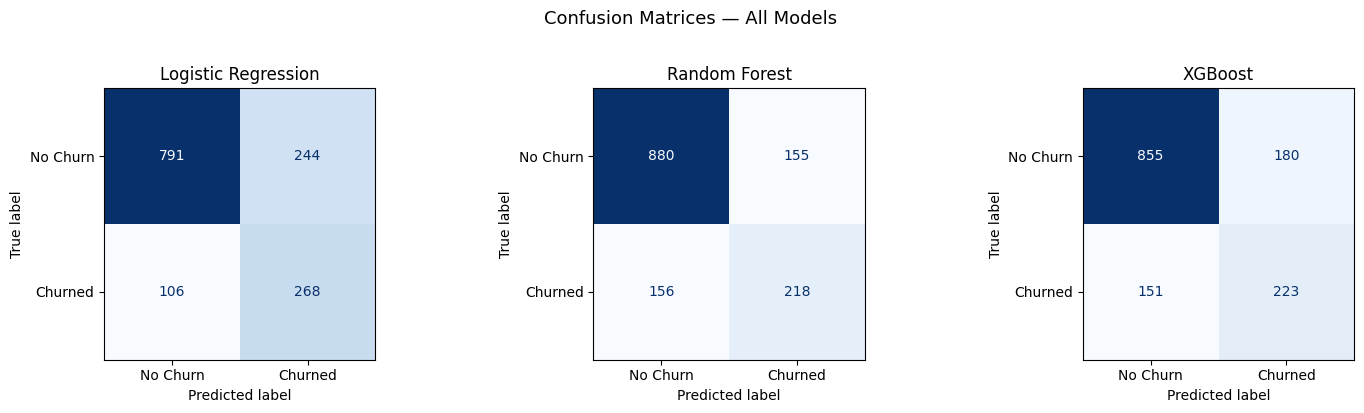

In [19]:
# Shows exactly how many customers were correctly and incorrectly classified.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_preds = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred)
]
for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices — All Models', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

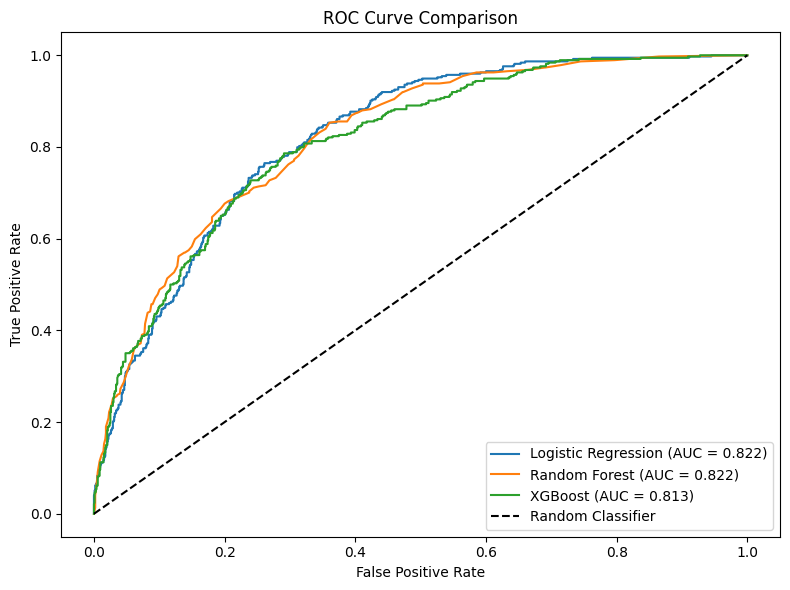

In [20]:
# The curve closest to the top-left corner is the best model. Save this chart for your README.

plt.figure(figsize=(8, 6))
for name, prob in [('Logistic Regression', lr_prob),
                   ('Random Forest', rf_prob),
                   ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

In [21]:
# Save XGBoost (your best model) so you can load it later without retraining.

import pickle
with open('xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
print("✅ Model saved as xgb_churn_model.pkl")
# Download to your computer
from google.colab import files
files.download('xgb_churn_model.pkl')

✅ Model saved as xgb_churn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# Create SHAP explainer using the trained XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print("✅ SHAP values calculated!")
print(f"Shape of SHAP values: {shap_values.shape}")
print(f"One SHAP value per feature ({X_test.shape[1]} features) per customer ({X_test.shape[0]} customers)")

✅ SHAP values calculated!
Shape of SHAP values: (1409, 19)
One SHAP value per feature (19 features) per customer (1409 customers)


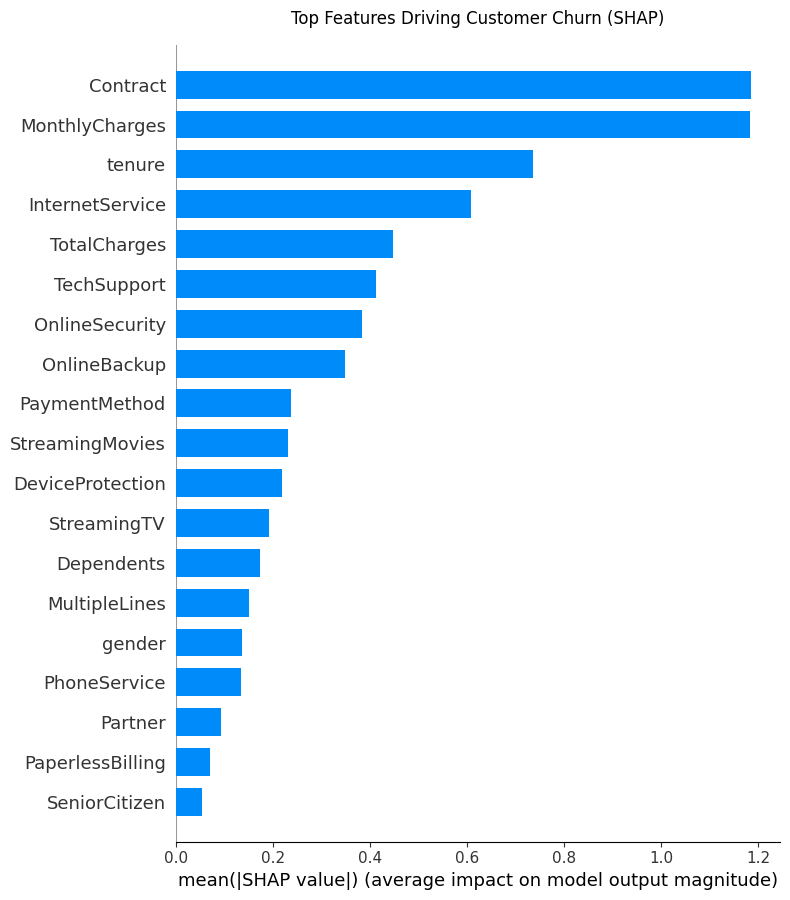


💡 The longer the bar, the more that feature impacts churn prediction.


In [23]:
#THIS is the chart that goes in your README and CV. It shows the top features driving churn.

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('Top Features Driving Customer Churn (SHAP)', pad=15)
plt.tight_layout()
plt.savefig('shap_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 The longer the bar, the more that feature impacts churn prediction.")

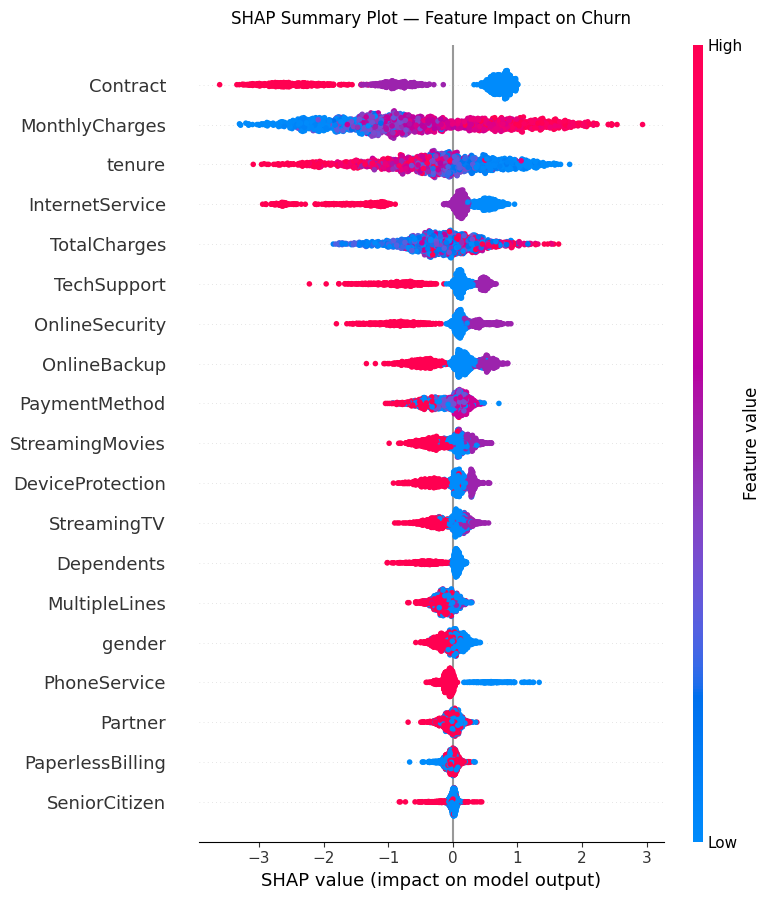


💡 Right side = pushes toward churn (1), Left side = pushes away from churn (0)


In [24]:
#More detailed than the bar chart — shows the direction of impact too. Red = high value, Blue = low value.

plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Right side = pushes toward churn (1), Left side = pushes away from churn (0)")

Found 172 high-risk customers (>80% churn probability)
Analysing customer at index: 1


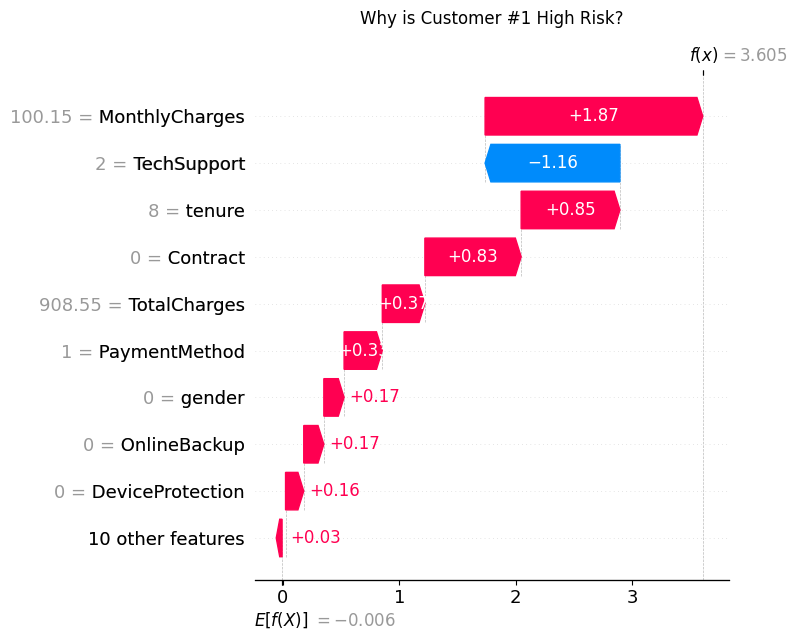

In [25]:
# Pick a customer the model predicted as high-risk and explain exactly why. This is the 'business recommendation' piece.

# Find a customer the model predicted as high churn risk
high_risk_idx = np.where(xgb_prob > 0.8)[0]
print(f"Found {len(high_risk_idx)} high-risk customers (>80% churn probability)")
print(f"Analysing customer at index: {high_risk_idx[0]}")
# Waterfall plot for that specific customer
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx[0]],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx[0]].values,
        feature_names=X.columns.tolist()
    ),
    show=False
)
plt.title(f'Why is Customer #{high_risk_idx[0]} High Risk?', pad=15)
plt.tight_layout()
plt.savefig('shap_waterfall_customer.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Get top 3 features for this customer
customer_shap = shap_values[high_risk_idx[0]]
feature_names = X.columns.tolist()
top_features = sorted(zip(feature_names, customer_shap),
                      key=lambda x: abs(x[1]), reverse=True)[:3]
churn_prob = xgb_prob[high_risk_idx[0]]
print("=" * 55)
print("   BUSINESS RECOMMENDATION — CHURN RISK REPORT")
print("=" * 55)
print(f"\n  Customer Index : {high_risk_idx[0]}")
print(f"  Churn Risk     : {churn_prob:.1%} (HIGH RISK)")
print("\n  Top 3 reasons this customer is likely to churn:")
for i, (feat, val) in enumerate(top_features, 1):
    direction = "↑ increases" if val > 0 else "↓ decreases"
    print(f"  {i}. {feat} — {direction} churn risk (SHAP={val:.3f})")
print("\n  Recommended Actions:")
print("  → Offer a long-term contract discount")
print("  → Assign a dedicated account manager")
print("  → Trigger a personalised retention campaign")
print("=" * 55)

   BUSINESS RECOMMENDATION — CHURN RISK REPORT

  Customer Index : 1
  Churn Risk     : 97.4% (HIGH RISK)

  Top 3 reasons this customer is likely to churn:
  1. MonthlyCharges — ↑ increases churn risk (SHAP=1.868)
  2. TechSupport — ↓ decreases churn risk (SHAP=-1.157)
  3. tenure — ↑ increases churn risk (SHAP=0.848)

  Recommended Actions:
  → Offer a long-term contract discount
  → Assign a dedicated account manager
  → Trigger a personalised retention campaign


In [27]:
#Downloads all the charts you created. Upload these to your GitHub repository.

from google.colab import files
import os
charts = [
    'churn_distribution.png',
    'churn_by_contract.png',
    'tenure_vs_charges.png',
    'correlation_heatmap.png',
    'confusion_matrices.png',
    'roc_curves.png',
    'shap_bar_chart.png',
    'shap_summary_plot.png',
    'shap_waterfall_customer.png'
]
print("Downloading charts...")
for chart in charts:
    if os.path.exists(chart):
        files.download(chart)
        print(f"  ✅ {chart}")
    else:
        print(f"  ⚠️  {chart} not found — did you run that cell?")
print("\nDone! Upload these to your GitHub outputs/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ churn_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ shap_summary_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ shap_waterfall_customer.png

Done! Upload these to your GitHub outputs/ folder.
